In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
xgb_pipeline = joblib.load("/kaggle/input/notebooks/madisrinija/03-classification-ipynb/xgb_at_risk_model.pkl")
lr_model = joblib.load("/kaggle/input/notebooks/madisrinija/04-regression-ipynb/linear_regression_model.pkl")
reg_preprocessor_pipeline = joblib.load("/kaggle/input/notebooks/madisrinija/04-regression-ipynb/regression_preprocessor_model.pkl")

In [4]:
df = pd.read_csv("/kaggle/input/notebooks/madisrinija/02-feature-engineering-ipynb/student_performance_dataset_cleaned.csv")
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,at_risk,academic_level,attendance_risk_level,sleep_deviation,deviation_bin,high_workload_low_sleep,engagement_score
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,0,excellent,Healthy,1.0,1.0,0,0.805426
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,0,excellent,Healthy,1.8,2.0,1,0.921053
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,0,excellent,Healthy,0.4,0.0,0,0.417909
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B,0,excellent,Healthy,0.5,0.0,0,0.592843
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,1,average,Healthy,2.9,3.0,1,0.331199


In [5]:
X = df.drop(columns=["final_grade", "at_risk"])
y = df["at_risk"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["at_risk"],
    test_size=0.2,
    random_state=42,
    stratify=df["at_risk"]
)

In [7]:
X_shap = X_test

### Classification SHAP

In [8]:
preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["xgb"]

In [9]:
print(xgb_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'academic_level',
       'attendance_risk_level'],
      dtype='object'))]), 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strateg

### Transform your data

In [10]:
X_transformed = preprocessor.transform(X_test)

In [11]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__gender_Female' 'cat__gender_Male'
 'cat__parental_education_Bachelors' 'cat__parental_education_High School'
 'cat__parental_education_Masters' 'cat__parental_education_PhD'
 'cat__parental_education_nan' 'cat__internet_access_No'
 'cat__internet_access_Yes' 'cat__extracurricular_activities_No'
 'cat__extracurricular_activities_Yes' 'cat__part_time_job_No'
 'cat__part_time_job_Yes' 'cat__academic_level_average'
 'cat__academic_level_excellent' 'cat__academic_level_poor'
 'cat__attendance_risk_level_Critical'
 'cat__attendance_risk_level_Healthy'
 'cat__attendance_risk_level_Moderate']


#### Create SHAP Explainer

In [12]:
explainer = shap.TreeExplainer(xgb_model)

In [13]:
shap_values = explainer.shap_values(X_transformed)

#### Global Feature Importance

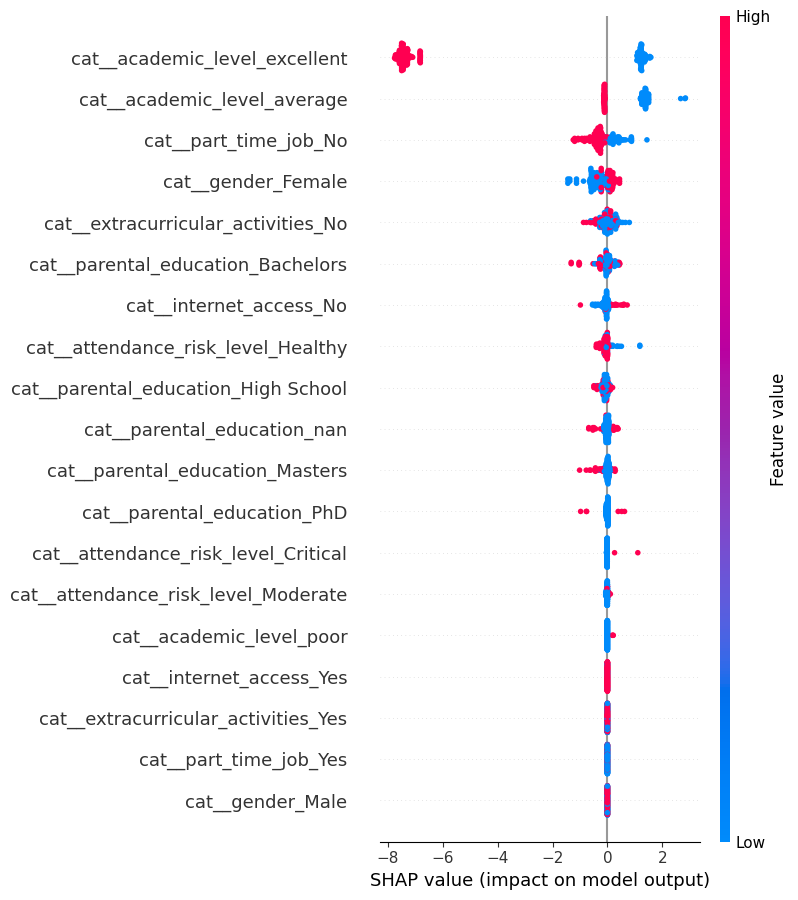

In [14]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

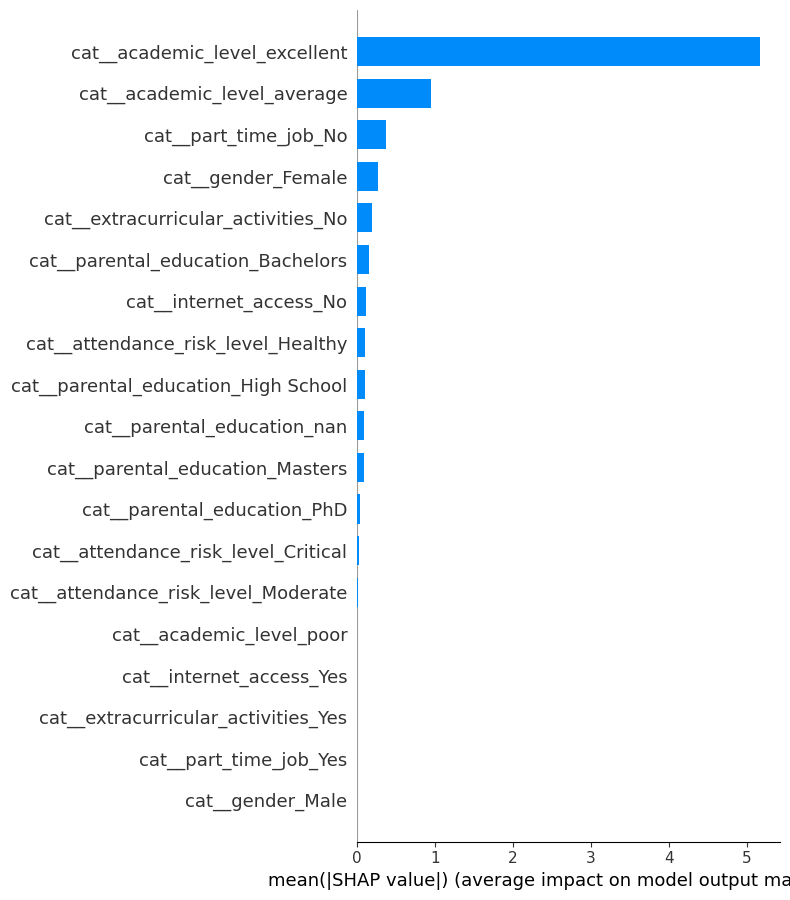

In [15]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

##### Explain one individual student

Risk Probability: 71.08%


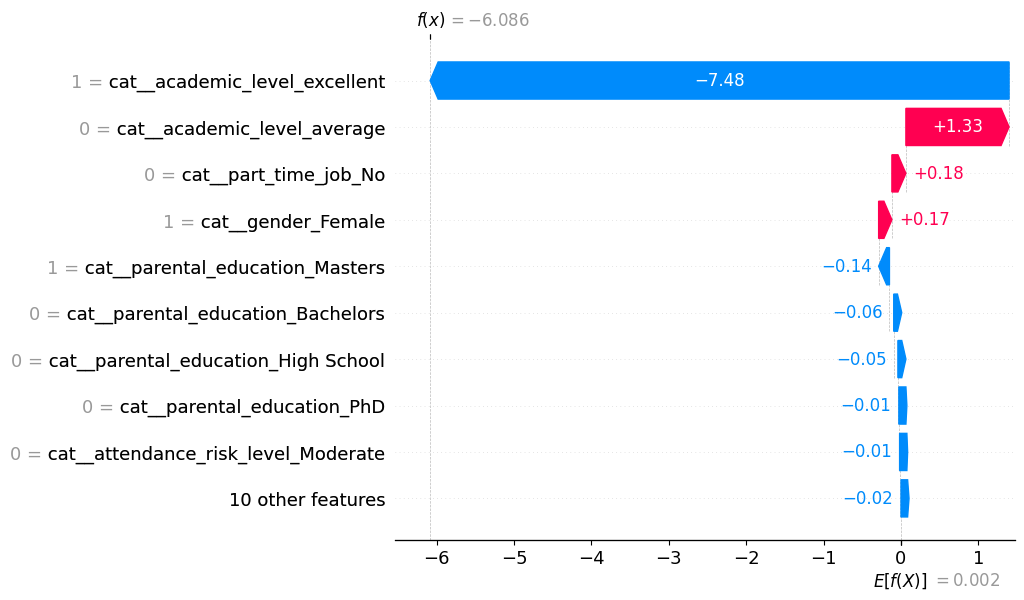

In [16]:
student_index = 75

student_raw = X.iloc[[student_index]]

risk_probability = xgb_pipeline.predict_proba(student_raw)[0][1]

print(f"Risk Probability: {risk_probability:.2%}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_index],
        base_values=explainer.expected_value,
        data=X_transformed[student_index],
        feature_names=feature_names
    )
)

##### Instead of manually choosing student_index = 0, find examples automatically.

In [17]:
risk_probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "index": X_test.index,
    "risk_probability": risk_probabilities
})

results.head()

,index,risk_probability
0,381,0.000606
1,732,0.685447
2,137,0.002459
3,467,0.001563
4,859,0.702749


In [18]:
def get_risk_level(prob):
    if prob >= 0.70:
        return "High"
    elif prob >= 0.15:
        return "Medium"
    else:
        return "Low"

results["risk_level"] = results["risk_probability"].apply(get_risk_level)

results.head()

,index,risk_probability,risk_level
0,381,0.000606,Low
1,732,0.685447,Medium
2,137,0.002459,Low
3,467,0.001563,Low
4,859,0.702749,High


In [19]:
results["risk_level"].value_counts()

risk_level
Low       134
High       34
Medium     32
Name: count, dtype: int64

In [20]:
low_student = results[
    results["risk_level"] == "Low"
].iloc[0]

medium_student = results[
    results["risk_level"] == "Medium"
].iloc[0]

high_student = results[
    results["risk_level"] == "High"
].iloc[0]

Select one student from each category

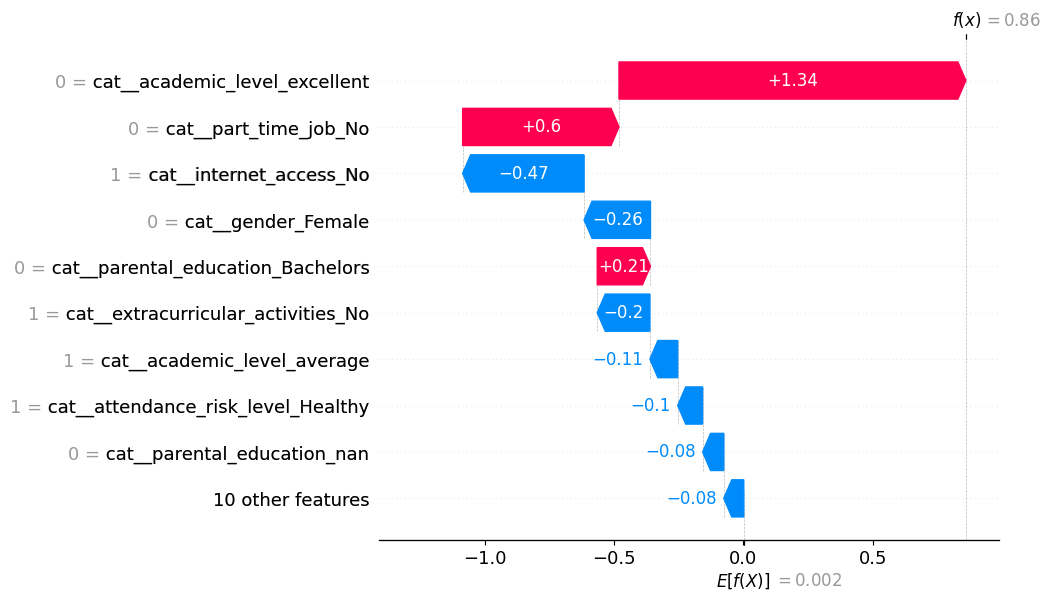

In [21]:
high_student_position = results.index.get_loc(high_student.name)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_student_position],
        base_values=explainer.expected_value,
        data=X_transformed[high_student_position],
        feature_names=feature_names
    )
)

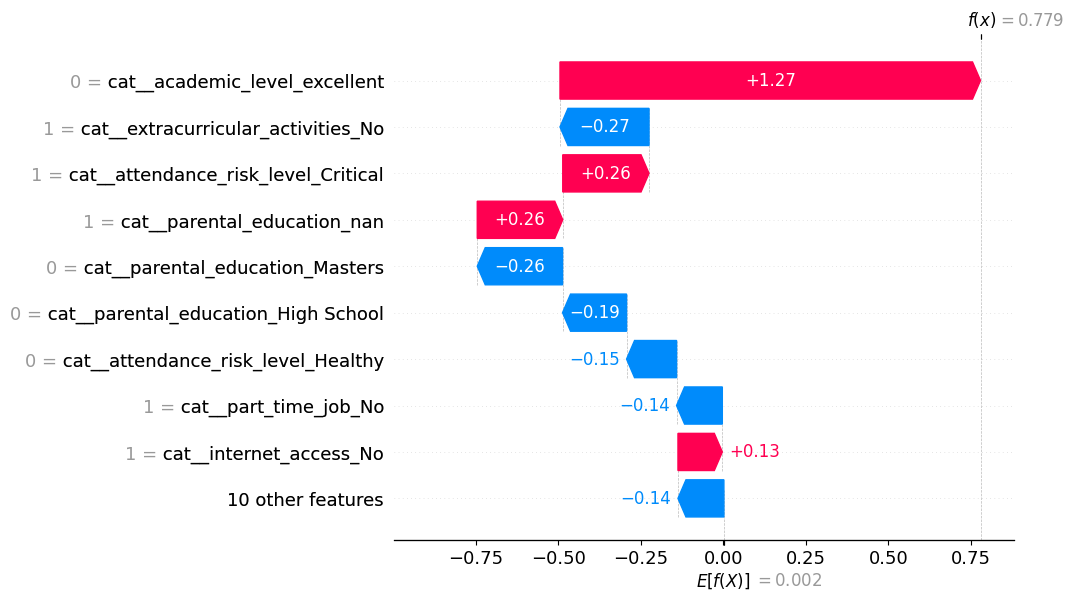

In [22]:
medium_student_position = results.index.get_loc(medium_student.name)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[medium_student_position],
        base_values=explainer.expected_value,
        data=X_transformed[medium_student_position],
        feature_names=feature_names
    )
)

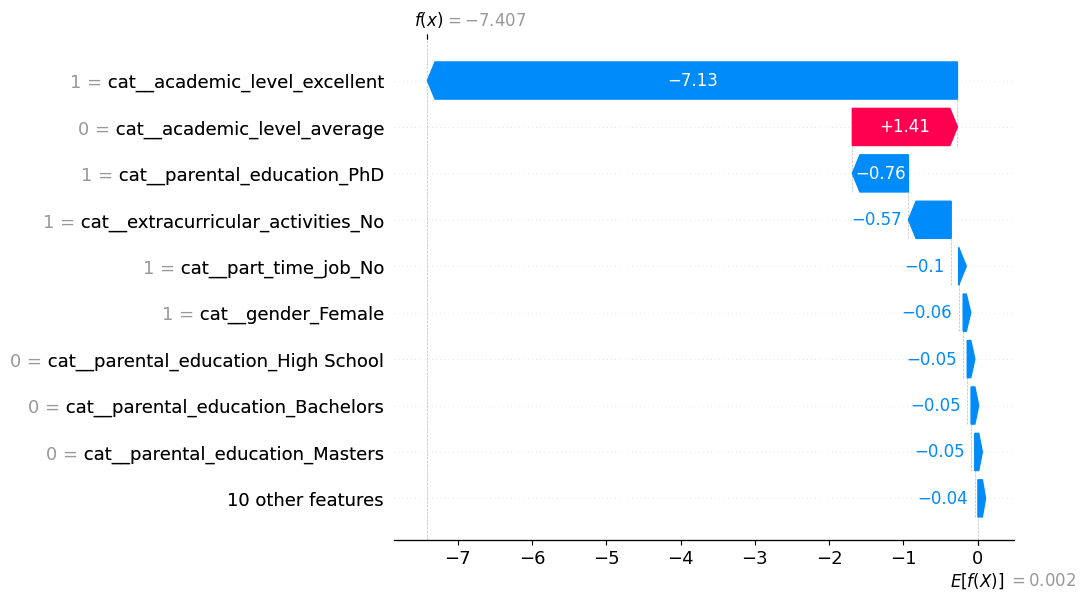

In [23]:
low_student_position = results.index.get_loc(low_student.name)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_student_position],
        base_values=explainer.expected_value,
        data=X_transformed[low_student_position],
        feature_names=feature_names
    )
)

## Regression Model

In [24]:
print(reg_preprocessor_pipeline.named_transformers_)

{'cat': OneHotEncoder(handle_unknown='ignore'), 'num': StandardScaler()}


In [25]:
ohe = reg_preprocessor_pipeline.named_transformers_['cat']
scaler = reg_preprocessor_pipeline.named_transformers_['num']

In [26]:
X_reg = df.drop(columns = ['student_id','final_grade','final_exam_score','at_risk','academic_level'])
y_reg = df['final_exam_score']

In [27]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [28]:
X_test_reg_transformed = reg_preprocessor_pipeline.transform(X_test_reg)

In [29]:
reg_feature_names = reg_preprocessor_pipeline.get_feature_names_out()

print(reg_feature_names)

['cat__gender_Female' 'cat__gender_Male'
 'cat__parental_education_Bachelors' 'cat__parental_education_High School'
 'cat__parental_education_Masters' 'cat__parental_education_PhD'
 'cat__parental_education_nan' 'cat__internet_access_No'
 'cat__internet_access_Yes' 'cat__extracurricular_activities_No'
 'cat__extracurricular_activities_Yes' 'cat__part_time_job_No'
 'cat__part_time_job_Yes' 'cat__attendance_risk_level_Critical'
 'cat__attendance_risk_level_Healthy'
 'cat__attendance_risk_level_Moderate' 'num__study_time_hours'
 'num__attendance_percent' 'num__sleep_hours' 'num__previous_grade'
 'num__sleep_deviation' 'num__deviation_bin'
 'num__high_workload_low_sleep' 'num__engagement_score']


In [30]:
explainer_lr = shap.LinearExplainer(
    lr_model,
    X_test_reg_transformed
)

shap_values_lr = explainer_lr.shap_values(
    X_test_reg_transformed
)

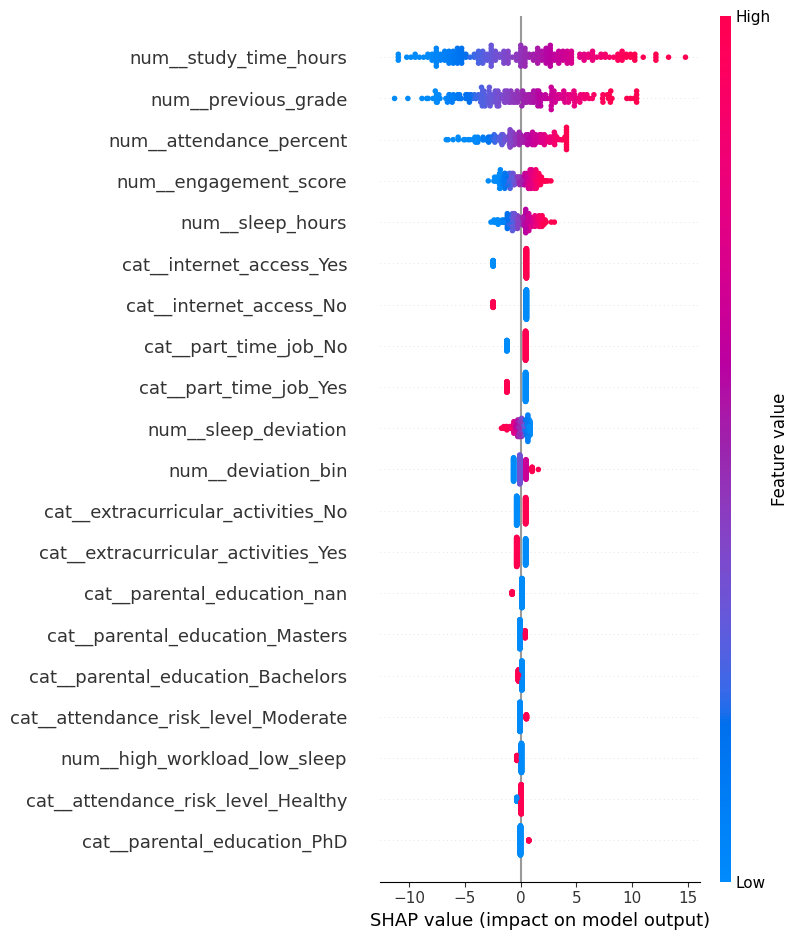

In [31]:
shap.summary_plot(
    shap_values_lr,
    X_test_reg_transformed,
    feature_names=reg_feature_names
)

In [32]:
student_position = 0

student_raw = X_test_reg.iloc[[student_position]]

# Transform
student_transformed = reg_preprocessor_pipeline.transform(student_raw)

# Predict
predicted_score = lr_model.predict(student_transformed)[0]

print(f"Predicted Final Exam Score: {predicted_score:.2f}")


Predicted Final Exam Score: 78.11


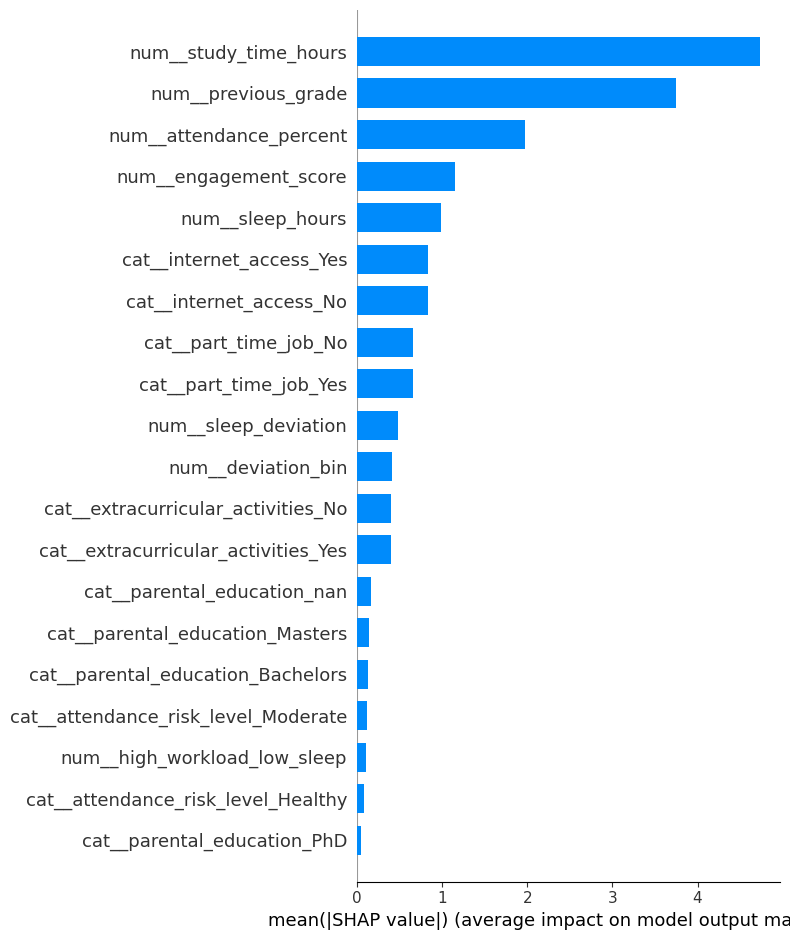

In [33]:
shap.summary_plot(
    shap_values_lr,
    X_test_reg_transformed,
    feature_names=reg_feature_names,
    plot_type="bar"
)

## Combine both models for one student

In [34]:
print(X_test.columns.tolist())
print(X_test_reg.columns.tolist())

['student_id', 'gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score', 'academic_level', 'attendance_risk_level', 'sleep_deviation', 'deviation_bin', 'high_workload_low_sleep', 'engagement_score']
['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'attendance_risk_level', 'sleep_deviation', 'deviation_bin', 'high_workload_low_sleep', 'engagement_score']


Don't assume position 0 in both test sets is automatically the same student. This is something we need to handle properly.

In [35]:
common_students = X_test.index.intersection(X_test_reg.index)

print(f"Common students: {len(common_students)}")
print(common_students[:10])

Common students: 33
Index([137, 859, 554, 120, 425, 30, 626, 741, 521, 312], dtype='int64')


In [36]:
student_id = common_students[3]

student_classification = X_test.loc[[student_id]]
student_regression = X_test_reg.loc[[student_id]]
student_classification

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,academic_level,attendance_risk_level,sleep_deviation,deviation_bin,high_workload_low_sleep,engagement_score
120,121,Female,2.6,92.0,10.0,High School,Yes,Yes,No,73.1,95.8,excellent,Healthy,2.5,2.0,0,0.699775


#### Get both predictions

In [37]:
risk_probability = xgb_pipeline.predict_proba(
    student_classification
)[0][1]

print(f"Risk Probability: {risk_probability:.2%}")

Risk Probability: 0.22%


In [38]:
student_reg_transformed = reg_preprocessor_pipeline.transform(
    student_regression
)

predicted_score = lr_model.predict(
    student_reg_transformed
)[0]

print(f"Predicted Final Exam Score: {predicted_score:.2f}")

Predicted Final Exam Score: 88.17


In [39]:
class_position = X_test.index.get_loc(student_id)

reg_position = X_test_reg.index.get_loc(student_id)

In [40]:
class_shap = shap_values[class_position]

reg_shap = shap_values_lr[reg_position]

## Create a reusable SHAP driver function

In [41]:
def get_top_drivers(shap_values_student, feature_names, top_n=5):
    
    drivers = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values_student
    })
    
    drivers["abs_impact"] = drivers["shap_value"].abs()
    
    drivers = drivers.sort_values(
        "abs_impact",
        ascending=False
    )
    
    return drivers.head(top_n)

In [42]:
def clean_feature_name(feature):
    
    # Remove transformer prefixes
    feature = feature.replace("cat__", "")
    feature = feature.replace("num__", "")
    
    # Replace underscores
    feature = feature.replace("_", " ")
    
    # Title case
    feature = feature.title()
    
    return feature

In [43]:
classification_drivers = get_top_drivers(
    shap_values[class_position],
    feature_names,
    top_n=5
)

classification_drivers

,feature,shap_value,abs_impact
14,cat__academic_level_excellent,-7.440403,7.440403
13,cat__academic_level_average,1.347060,1.347060
11,cat__part_time_job_No,-0.206827,0.206827
9,cat__extracurricular_activities_No,0.138665,0.138665
0,cat__gender_Female,0.094668,0.094668


In [44]:
classification_drivers["clean_feature"] = (
    classification_drivers["feature"]
    .apply(clean_feature_name)
)

classification_drivers

,feature,shap_value,abs_impact,clean_feature
14,cat__academic_level_excellent,-7.440403,7.440403,Academic Level Excellent
13,cat__academic_level_average,1.347060,1.347060,Academic Level Average
11,cat__part_time_job_No,-0.206827,0.206827,Part Time Job No
9,cat__extracurricular_activities_No,0.138665,0.138665,Extracurricular Activities No
0,cat__gender_Female,0.094668,0.094668,Gender Female


In [45]:
regression_drivers = get_top_drivers(
    shap_values_lr[reg_position],
    reg_feature_names,
    top_n=5
)

regression_drivers

,feature,shap_value,abs_impact
16,num__study_time_hours,-3.025002,3.025002
18,num__sleep_hours,3.016419,3.016419
17,num__attendance_percent,1.869243,1.869243
23,num__engagement_score,1.209605,1.209605
19,num__previous_grade,0.944982,0.944982


In [46]:
regression_drivers["clean_feature"] = (
    regression_drivers["feature"]
    .apply(clean_feature_name)
)

regression_drivers

,feature,shap_value,abs_impact,clean_feature
16,num__study_time_hours,-3.025002,3.025002,Study Time Hours
18,num__sleep_hours,3.016419,3.016419,Sleep Hours
17,num__attendance_percent,1.869243,1.869243,Attendance Percent
23,num__engagement_score,1.209605,1.209605,Engagement Score
19,num__previous_grade,0.944982,0.944982,Previous Grade


In [47]:
risk_increasing = classification_drivers[
    classification_drivers["shap_value"] > 0
]

risk_reducing = classification_drivers[
    classification_drivers["shap_value"] < 0
]

In [48]:
score_increasing = regression_drivers[
    regression_drivers["shap_value"] > 0
]

score_decreasing = regression_drivers[
    regression_drivers["shap_value"] < 0
]

#### Add contribution direction

Regression

For predicted exam score:


* Positive SHAP → increases predicted score
* Negative SHAP → decreases predicted score


In [49]:
regression_drivers["contribution"] = regression_drivers[
    "shap_value"
].apply(
    lambda x: "Increases Predicted Score" if x > 0 else "Decreases Predicted Score"
)

regression_drivers

,feature,shap_value,abs_impact,clean_feature,contribution
16,num__study_time_hours,-3.025002,3.025002,Study Time Hours,Decreases Predicted Score
18,num__sleep_hours,3.016419,3.016419,Sleep Hours,Increases Predicted Score
17,num__attendance_percent,1.869243,1.869243,Attendance Percent,Increases Predicted Score
23,num__engagement_score,1.209605,1.209605,Engagement Score,Increases Predicted Score
19,num__previous_grade,0.944982,0.944982,Previous Grade,Increases Predicted Score


Classification

For risk classification:


* Positive SHAP → increases risk
* Negative SHAP → reduces risk 


In [50]:
classification_drivers["contribution"] = classification_drivers[
    "shap_value"
].apply(
    lambda x: "Increases Risk" if x > 0 else "Reduces Risk"
)

classification_drivers

,feature,shap_value,abs_impact,clean_feature,contribution
14,cat__academic_level_excellent,-7.440403,7.440403,Academic Level Excellent,Reduces Risk
13,cat__academic_level_average,1.347060,1.347060,Academic Level Average,Increases Risk
11,cat__part_time_job_No,-0.206827,0.206827,Part Time Job No,Reduces Risk
9,cat__extracurricular_activities_No,0.138665,0.138665,Extracurricular Activities No,Increases Risk
0,cat__gender_Female,0.094668,0.094668,Gender Female,Increases Risk


Then create the first combined advisor report

In [51]:
def get_risk_level(probability):
    
    if probability >= 0.70:
        return "HIGH RISK"
    elif probability >= 0.15:
        return "MEDIUM RISK"
    else:
        return "LOW RISK"

In [52]:
def generate_student_summary(
    student_id,
    risk_probability,
    predicted_score
):
    
    risk_level = get_risk_level(risk_probability)
    
    print("=" * 55)
    print(f"STUDENT #{student_id} — {risk_level}")
    print("=" * 55)
    
    print("\nRISK ASSESSMENT")
    print(f"Risk Probability: {risk_probability:.2%}")
    
    print("\nACADEMIC PERFORMANCE FORECAST")
    print(f"Predicted Final Exam Score: {predicted_score:.2f}")

In [53]:
generate_student_summary(
    student_id=student_id,
    risk_probability=risk_probability,
    predicted_score=predicted_score
)

STUDENT #120 — LOW RISK

RISK ASSESSMENT
Risk Probability: 0.22%

ACADEMIC PERFORMANCE FORECAST
Predicted Final Exam Score: 88.17


## Build human-readable driver tables with feature values

In [54]:
def get_original_feature_name(feature_name):

    # Remove preprocessing prefixes
    name = feature_name.replace("cat__", "")
    name = name.replace("num__", "")

    categorical_features = [
        "gender",
        "parental_education",
        "internet_access",
        "part_time_job",
        "academic_level",
        "attendance_risk_level"
    ]

    # Map encoded categories back to original feature
    for feature in categorical_features:
        if name.startswith(feature + "_"):
            return feature

    return name

In [55]:
def aggregate_shap_by_feature(
    shap_values_student,
    transformed_feature_names,
    top_n=5
):

    df_shap = pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "shap_value": shap_values_student
    })

    df_shap["original_feature"] = (
        df_shap["transformed_feature"]
        .apply(get_original_feature_name)
    )

    # Combine SHAP contributions
    aggregated = (
        df_shap
        .groupby("original_feature", as_index=False)["shap_value"]
        .sum()
    )

    aggregated["abs_impact"] = (
        aggregated["shap_value"].abs()
    )

    return aggregated.sort_values(
        "abs_impact",
        ascending=False
    ).head(top_n)

In [56]:
classification_drivers_corrected = aggregate_shap_by_feature(
    shap_values[class_position],
    feature_names,
    top_n=5
)

student_raw = student_classification.iloc[0]

classification_drivers_corrected["student_value"] = (
    classification_drivers_corrected["original_feature"]
    .map(student_raw)
)

classification_drivers_corrected

,original_feature,shap_value,abs_impact,student_value
0,academic_level,-6.095033,6.095033,excellent
7,part_time_job,-0.206827,0.206827,No
2,extracurricular_activities_No,0.138665,0.138665,NaN
4,gender,0.094668,0.094668,Female
6,parental_education,-0.059525,0.059525,High School


In [57]:
regression_drivers_corrected = aggregate_shap_by_feature(
    shap_values_lr[reg_position],
    reg_feature_names,
    top_n=5
)

student_reg_raw = student_regression.iloc[0]

regression_drivers_corrected["student_value"] = (
    regression_drivers_corrected["original_feature"]
    .map(student_reg_raw)
)

regression_drivers_corrected

,original_feature,shap_value,abs_impact,student_value
14,study_time_hours,-3.025002,3.025002,2.6
13,sleep_hours,3.016419,3.016419,10.0
0,attendance_percent,1.869243,1.869243,92.0
3,engagement_score,1.209605,1.209605,0.699775
8,internet_access,1.012965,1.012965,Yes


In [58]:
def create_shap_explanation(
    drivers,
    raw_student,
    model_type="classification"
):
    
    explanation = drivers.copy()
    
    # Clean feature names
    explanation["clean_feature"] = (
        explanation["original_feature"]
        .apply(clean_feature_name)
    )
    
    # Add contribution direction
    if model_type == "classification":
        explanation["contribution"] = explanation["shap_value"].apply(
            lambda x: "Increases Risk" if x > 0 else "Reduces Risk"
        )
    else:
        explanation["contribution"] = explanation["shap_value"].apply(
            lambda x: "Increases Predicted Score"
            if x > 0 else
            "Decreases Predicted Score"
        )
    
    return explanation

In [59]:
def readable_feature(feature_name):
    
    # Remove prefixes
    name = feature_name.replace("cat__", "")
    name = name.replace("num__", "")
    
    # Categorical features
    categorical_features = [
        "gender",
        "parental_education",
        "internet_access",
        "part_time_job",
        "academic_level",
        "attendance_risk_level"
    ]
    
    for feature in categorical_features:
        
        if name.startswith(feature + "_"):
            
            value = name.replace(feature + "_", "")
            
            return (
                feature.replace("_", " ").title()
                + ": "
                + value.title()
            )
    
    # Numerical feature
    return name.replace("_", " ").title()

In [60]:
classification_drivers["display_feature"] = (
    classification_drivers["feature"]
    .apply(readable_feature)
)

regression_drivers["display_feature"] = (
    regression_drivers["feature"]
    .apply(readable_feature)
)

In [61]:
def impact_strength(rank):
    if rank == 1:
        return "Primary"
    elif rank <= 3:
        return "Significant"
    else:
        return "Secondary"


classification_drivers_corrected["strength"] = (
    classification_drivers_corrected["abs_impact"]
    .apply(impact_strength)
)

regression_drivers_corrected["strength"] = (
    regression_drivers_corrected["abs_impact"]
    .apply(impact_strength)
)

In [62]:
def generate_full_advisor_report(
    student_id,
    risk_probability,
    predicted_score,
    classification_drivers,
    regression_drivers
):

    # Risk level
    if risk_probability >= 0.70:
        risk_level = "HIGH RISK 🚨"
    elif risk_probability >= 0.30:
        risk_level = "MEDIUM RISK ⚠️"
    else:
        risk_level = "LOW RISK 🟢"

    print("=" * 60)
    print(f"STUDENT #{student_id} — {risk_level}")
    print("=" * 60)

    print("\nRISK ASSESSMENT")
    print(f"Risk Probability: {risk_probability:.2%}")

    print("\nPERFORMANCE FORECAST")
    print(f"Predicted Final Exam Score: {predicted_score:.2f}")

    # Separate classification factors
    risk_increasing = classification_drivers[
        classification_drivers["shap_value"] > 0
    ]

    risk_reducing = classification_drivers[
        classification_drivers["shap_value"] < 0
    ]

    print("\nRISK-INCREASING FACTORS")

    if len(risk_increasing) == 0:
        print("No major risk-increasing factors identified.")

    for _, row in risk_increasing.iterrows():

        feature = row["original_feature"].replace("_", " ").title()

        print(f"{feature}: {row['student_value']}")
        print(
            f"   → {row['strength']} contribution toward higher predicted risk"
        )
        print()
    print()
    
    print("\nPROTECTIVE FACTORS")

    for _, row in risk_reducing.iterrows():

        feature = row["original_feature"].replace("_", " ").title()

        print(f"{feature}: {row['student_value']}")
        print(
            f"   → {row['strength']} contribution toward lower predicted risk"
        )
        print()
    print()

    # Regression factors
    score_increasing = regression_drivers[
        regression_drivers["shap_value"] > 0
    ]

    score_decreasing = regression_drivers[
        regression_drivers["shap_value"] < 0
    ]

    print("\nSCORE-INCREASING FACTORS")

    for _, row in score_increasing.iterrows():

        feature = row["original_feature"].replace("_", " ").title()

        print(f"{feature}: {row['student_value']}")
        print(
            f"   → {row['strength']} positive contribution"
        )
        print()

    print()

    print("\nSCORE-DECREASING FACTORS")

    for _, row in score_decreasing.iterrows():

        feature = row["original_feature"].replace("_", " ").title()

        print(f"{feature}: {row['student_value']}")
        print(
            f"   → {row['strength']} negative contribution"
        )
        print()

    print("\n" + "=" * 60)

In [63]:
generate_full_advisor_report(
    student_id,
    risk_probability,
    predicted_score,
    classification_drivers_corrected,
    regression_drivers_corrected
)

STUDENT #120 — LOW RISK 🟢

RISK ASSESSMENT
Risk Probability: 0.22%

PERFORMANCE FORECAST
Predicted Final Exam Score: 88.17

RISK-INCREASING FACTORS
Extracurricular Activities No: nan
   → Significant contribution toward higher predicted risk

Gender: Female
   → Significant contribution toward higher predicted risk



PROTECTIVE FACTORS
Academic Level: excellent
   → Secondary contribution toward lower predicted risk

Part Time Job: No
   → Significant contribution toward lower predicted risk

Parental Education: High School
   → Significant contribution toward lower predicted risk



SCORE-INCREASING FACTORS
Sleep Hours: 10.0
   → Secondary positive contribution

Attendance Percent: 92.0
   → Significant positive contribution

Engagement Score: 0.6997748796770688
   → Significant positive contribution

Internet Access: Yes
   → Significant positive contribution



SCORE-DECREASING FACTORS
Study Time Hours: 2.6
   → Secondary negative contribution




# Recommended Intervention Engine.

In [64]:
INTERVENTION_RULES = {

    "attendance_percent": {
        "high": {
            "recommendation": "Immediate Academic Advisor Check-In",
            "reason": "Low attendance is strongly associated with academic risk."
        },
        "medium": {
            "recommendation": "Attendance Improvement Plan",
            "reason": "Attendance patterns may negatively affect academic progress."
        },
        "low": {
            "recommendation": "Routine Attendance Monitoring",
            "reason": "Continue monitoring attendance patterns."
        }
    },
        "attendance_risk_level": {
        "high": {
            "recommendation": "Immediate Attendance Intervention",
            "reason": "The student's attendance risk level requires immediate attention."
        },
        "moderate": {
            "recommendation": "Attendance Improvement Plan",
            "reason": "Attendance requires targeted monitoring and support."
        },
        "healthy": {
            "recommendation": "No Attendance Intervention Needed",
            "reason": "Current attendance pattern appears healthy."
        }
    },
        "study_time_hours": {
        "high": {
            "recommendation": "Personalized Study Plan",
            "reason": "Study time may be insufficient for academic requirements."
        },
        "medium": {
            "recommendation": "Time Management and Study Skills Support",
            "reason": "Improving study routines may support academic performance."
        },
        "low": {
            "recommendation": "Maintain Current Study Routine",
            "reason": "Current study habits appear supportive."
        }
    },
        "engagement_score": {
        "high": {
            "recommendation": "Student Engagement and Mentoring Program",
            "reason": "Low engagement may indicate reduced academic participation."
        },
        "medium": {
            "recommendation": "Faculty or Peer Mentoring Check-In",
            "reason": "Additional engagement support may improve participation."
        },
        "low": {
            "recommendation": "Routine Engagement Monitoring",
            "reason": "Continue monitoring student participation."
        }
    },
        "previous_grade": {
        "high": {
            "recommendation": "Academic Tutoring and Recovery Plan",
            "reason": "Previous academic performance suggests a need for intensive support."
        },
        "medium": {
            "recommendation": "Subject-Specific Academic Support",
            "reason": "Additional academic guidance may improve future performance."
        },
        "low": {
            "recommendation": "Maintain Academic Progress",
            "reason": "Previous academic performance is satisfactory."
        }
    },
        "part_time_job": {
        "high": {
            "recommendation": "Academic Workload and Financial Support Consultation",
            "reason": "External work commitments may be affecting academic balance."
        },
        "medium": {
            "recommendation": "Workload Management Consultation",
            "reason": "Review balance between employment and academic responsibilities."
        },
        "low": {
            "recommendation": "No Intervention Based on Employment Status Alone",
            "reason": "Employment status alone should not trigger intervention."
        }
    },
        "internet_access": {
        "high": {
            "recommendation": "Technology and Digital Access Support",
            "reason": "Limited internet access may restrict access to academic resources."
        },
        "medium": {
            "recommendation": "Campus Digital Resource Support",
            "reason": "Ensure the student has reliable access to required learning resources."
        },
        "low": {
            "recommendation": "No Digital Access Intervention Needed",
            "reason": "Current internet access appears adequate."
        }
    }
}

In [65]:
ACTIONABLE_FEATURES = [
    "attendance_percent",
    "attendance_risk_level",
    "study_time_hours",
    "engagement_score",
    "previous_grade",
    "part_time_job",
    "internet_access"
]
non_actionable_features = [
    "gender",
    "parental_education",
]

In [66]:
severity_thresholds = {

    "attendance_percent": {
        "high": 60,
        "medium": 75
    },

    "study_time_hours": {
        "high": 2,
        "medium": 4
    },

    "engagement_score": {
        "high": 0.3,
        "medium": 0.5
    },

    "previous_grade": {
        "high": 50,
        "medium": 65
    }
}

In [67]:
def get_categorical_severity(feature, value):
    
    value = str(value).lower()
    
    if feature == "attendance_risk_level":
        
        if value in ["high", "poor", "critical"]:
            return "high"
        elif value in ["medium", "moderate", "at_risk"]:
            return "medium"
    
    elif feature == "internet_access":
        
        if value == "no":
            return "high"
    
    return None

In [68]:
def get_feature_severity(feature, value):
    thresholds = severity_thresholds.get(feature)
    
    # 1. Dynamically handle numeric features using the dictionary
    if thresholds:
        if value < thresholds["high"]:
            return "high"
        elif value < thresholds["medium"]:
            return "medium"
        else:
            return "low"  # Safe default fallback for good scores
            
    # 2. Handle categorical strings that aren't in the thresholds dictionary
    if feature == "part_time_job" :
        if str(value).strip().lower() == "yes":
            return "medium"
        else:
            return "low"

    if feature == "internet_access":  # Fixed: Removed the extra double quote here
        if str(value).strip().lower() == "no":
            return "high"             # No internet access creates high risk
        elif str(value).strip().lower() == "poor":
            return "medium"           # Bad connection creates medium risk
        else:
            return "low" 
            
    return None


In [69]:
def identify_intervention_needs(
    classification_drivers,
    regression_drivers
):
    
    needs = []
    
    # ---- Classification model ----
    # Positive SHAP = increases risk
    
    for _, row in classification_drivers.iterrows():
        
        feature = row["original_feature"]
        value = row["student_value"]
        shap_value = row["shap_value"]
        
        if feature not in ACTIONABLE_FEATURES:
            continue
        
        # Check numerical severity
        severity = get_feature_severity(feature, value)
        
        # Check categorical severity
        if severity is None:
            severity = get_categorical_severity(feature, value)
        
        # Only trigger if:
        # feature has concerning value AND increases risk
        if severity and shap_value > 0:
            
            needs.append({
                "feature": feature,
                "value": value,
                "severity": severity,
                "source": "risk_model",
                "shap_impact": abs(shap_value)
            })
    
    
    # ---- Regression model ----
    # Negative SHAP = decreases predicted score
    
    for _, row in regression_drivers.iterrows():
        
        feature = row["original_feature"]
        value = row["student_value"]
        shap_value = row["shap_value"]
        
        if feature not in ACTIONABLE_FEATURES:
            continue
        
        severity = get_feature_severity(feature, value)
        
        if severity is None:
            severity = get_categorical_severity(feature, value)
        
        # Concerning feature + decreases score
        if severity and shap_value < 0:
            
            needs.append({
                "feature": feature,
                "value": value,
                "severity": severity,
                "source": "performance_model",
                "shap_impact": abs(shap_value)
            })
    
    return needs

In [70]:
intervention_needs = identify_intervention_needs(
    classification_drivers_corrected,
    regression_drivers_corrected
)

pd.DataFrame(intervention_needs)

,feature,value,severity,source,shap_impact
0,study_time_hours,2.6,medium,performance_model,3.025002


In [71]:
def generate_interventions(intervention_needs):
    # Change recommendations to a dictionary keyed by the recommendation text
    recommendations_dict = {}
    
    for need in intervention_needs:
        feature = need["feature"]
        severity = need["severity"]
        
        if feature in INTERVENTION_RULES:
            recommendation_data = INTERVENTION_RULES[feature].get(severity)
            
            if recommendation_data:
                rec_text = recommendation_data.get("recommendation")
                new_reason = f"Concerning {feature.replace('_', ' ')} value: {need['value']}"
                
                # If we've already seen this recommendation, append the new reason
                if rec_text in recommendations_dict:
                    recommendations_dict[rec_text]["reason"] += f" | {new_reason}"
                else:
                    # Otherwise, create a new entry
                    recommendations_dict[rec_text] = {
                        "recommendation": rec_text,
                        "feature": feature,  # Tracks the first feature that triggered it
                        "severity": severity,
                        "reason": new_reason
                    }
    
    # Return a clean list of dictionaries just like before
    return list(recommendations_dict.values())


In [72]:
recommendations = generate_interventions(
    intervention_needs
)

recommendations

[{'recommendation': 'Time Management and Study Skills Support',
  'feature': 'study_time_hours',
  'severity': 'medium',
  'reason': 'Concerning study time hours value: 2.6'}]

In [73]:
def get_intervention_priority(
    risk_probability,
    predicted_score
):
    
    if risk_probability >= 0.70 or predicted_score < 50:
        return "HIGH"
    
    elif risk_probability >= 0.30 or predicted_score < 65:
        return "MEDIUM"
    
    else:
        return "LOW"

In [74]:
def get_final_recommendations(
    risk_probability,
    predicted_score,
    recommendations
):
    
    priority = get_intervention_priority(
        risk_probability,
        predicted_score
    )
    
    # Low-risk + good predicted performance
    if priority == "LOW":
        
        return {
            "priority": "LOW",
            "action": "Routine Monitoring",
            "recommendations": [
                {
                    "recommendation": "Continue Routine Academic Monitoring",
                    "reason": "The student currently demonstrates low predicted risk and satisfactory expected performance."
                }
            ]
        }
    
    if not recommendations:
        return {
            "priority": priority,
            "action": "Advisor Review Recommended",
            "recommendations": [
                {
                    "recommendation": "Academic Advisor Review",
                    "reason": (
                        "The prediction indicates potential concern, "
                        "but no specific actionable factor met the "
                        "automated intervention criteria."
                    )
                }
            ]
        }
        
    # Medium / High priority
    return {
        "priority": priority,
        "action": "Targeted Intervention",
        "recommendations": recommendations
    }

In [75]:
# 1. Identify concerns
intervention_needs = identify_intervention_needs(
    classification_drivers_corrected,
    regression_drivers_corrected
)

# 2. Generate recommendations
recommendations = generate_interventions(
    intervention_needs
)

# 3. Apply overall priority
final_intervention = get_final_recommendations(
    risk_probability,
    predicted_score,
    recommendations
)

final_intervention

{'priority': 'LOW',
 'action': 'Routine Monitoring',
 'recommendations': [{'recommendation': 'Continue Routine Academic Monitoring',
   'reason': 'The student currently demonstrates low predicted risk and satisfactory expected performance.'}]}